In [73]:
import timeit
import numpy as np
import matplotlib.pyplot as plt
import biosppy.signals.tools as to

In [74]:
# Load some samples
import os
from scipy.io import loadmat

def load_challenge_data(filename):
    x = loadmat(filename)
    data = np.asarray(x['val'], dtype=np.float64)

    new_file = filename.replace('.mat', '.hea')
    input_header_file = os.path.join(new_file)
    with open(input_header_file, 'r') as f:
        header_data = f.readlines()
    return data, header_data


float64


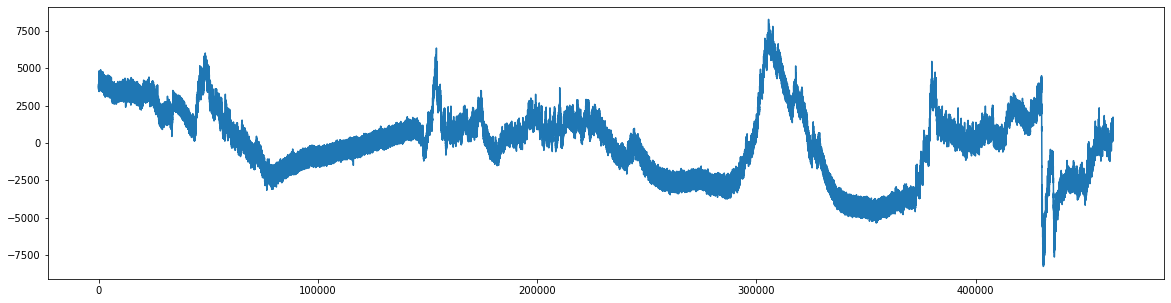

In [75]:
data_in, header = load_challenge_data("../utils/temp/I0001.mat")
print(data_in.dtype)
fig = plt.figure(figsize=(20, 5))
plt.plot(data_in[0, :])
plt.show()

In [89]:
def remove_baseline_wander_v1(data_in):
    data_out = np.empty(data_in.shape, dtype=data_in.dtype)
    for i in range(data_in.shape[0]):
        # Uses a forward-backward filter implementation. Therefore, the combined filter has linear phase.
        data_out[i, :], fs, params = to.filter_signal(
            signal=data_in[i, :],
            ftype='FIR',
            band='highpass',
            order=1021,
            frequency=0.25,
            sampling_rate=500.0)
    return data_out

def remove_baseline_wander_v2(data_in):
    data_out = np.empty(data_in.shape, dtype=data_in.dtype)
    for i in range(data_in.shape[0]):
        # Uses a forward-backward filter implementation. Therefore, the combined filter has linear phase.
        data_out[i, :], fs, params = to.filter_signal(
            signal=data_in[i, :],
            ftype='bessel',
            band='highpass',
            order=5,
            frequency=0.15,
            sampling_rate=500.0)
    return data_out

data_out_1 = remove_baseline_wander_v1(data_in)
data_out_2 = remove_baseline_wander_v2(data_in)

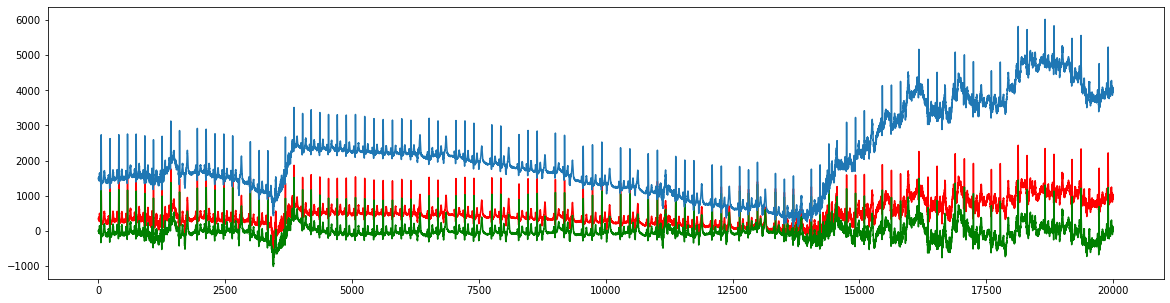

In [90]:
fig = plt.figure(figsize=(20, 5))
plt.plot(data_out_1[0, 30000:50000], color='red')
plt.plot(data_out_2[0, 30000:50000], color='green')
plt.plot(data_in[0, 30000:50000])
plt.show()

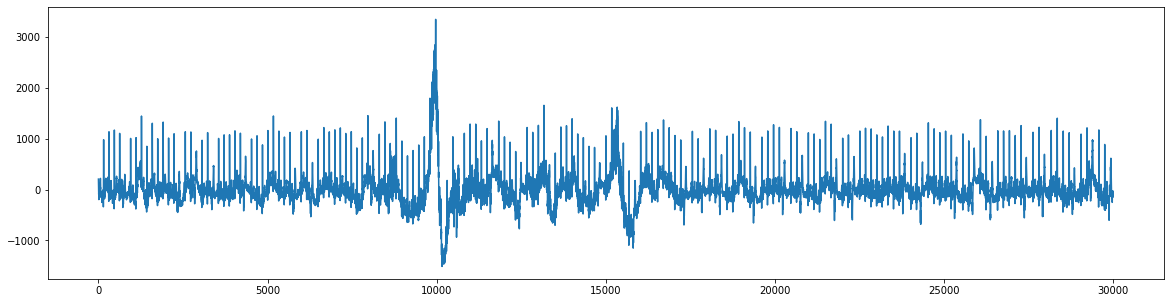

In [62]:
fig = plt.figure(figsize=(20, 5))
plt.plot(data_out[0, 420000:450000])
plt.plot(data_in[0, 420000:450000])
plt.show()

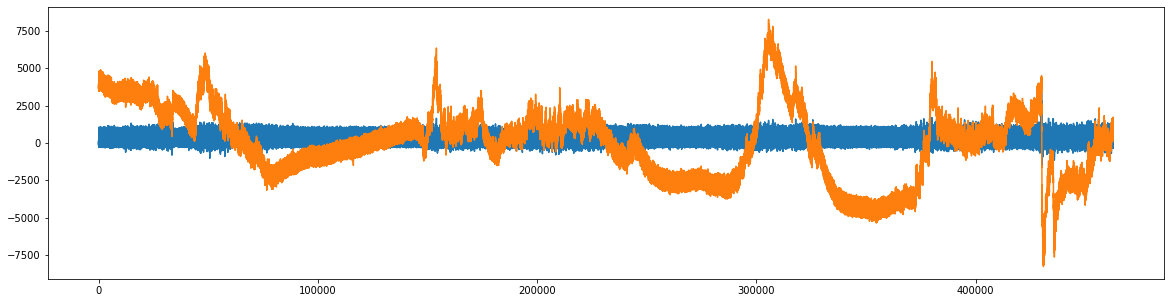

In [91]:
fig = plt.figure(figsize=(20, 5))
plt.plot(data_out[0, :])
plt.plot(data_in[0, :])
plt.show()

In [93]:
a = timeit.Timer( lambda: remove_baseline_wander_v1(data_in))
time = a.timeit(10) / 10.
print("One ecg takes:", time, "seconds")

a = timeit.Timer( lambda: remove_baseline_wander_v2(data_in))
time = a.timeit(10) / 10.
print("One ecg takes:", time, "seconds")

One ecg takes: 1.3671172639999896 seconds
One ecg takes: 0.1187476062999849 seconds


In [9]:
# Filter order very high --> smalles possible input length 3072
a = np.empty((12, 3072), dtype=data_in.dtype)
a.shape
remove_baseline_wander(a)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [97]:
data_in, header = load_challenge_data("../utils/temp/HR00003.mat")
data_out = remove_baseline_wander_v1(data_in)

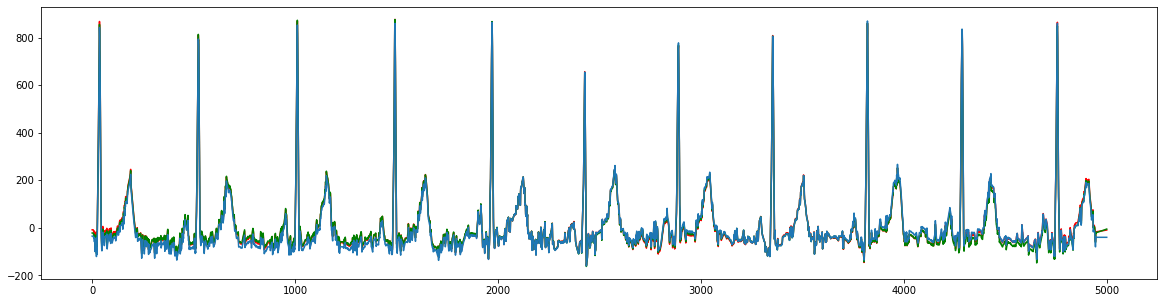

In [105]:
fig = plt.figure(figsize=(20, 5))
plt.plot(remove_baseline_wander_v1(data_in)[0, :], color='red')
plt.plot(remove_baseline_wander_v2(data_in)[0, :], color='green')
plt.plot(data_in[0, :])
plt.show()

In [102]:
np.mean(data_out), np.mean(data_in), np.var(data_out), np.var(data_in)

(1.5959960965481588,
 1.5194333333333334,
 12621.563039792576,
 16285.611922345557)